In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Experiment 1

In [67]:
# create function to load the f1 scores of selected experiment and dataset
def load_f1_dev_by_epoch(experiment_number, dataset = None):
    base_path = f"{experiment_number}/"
    all_prefixes = ["iemocap", "meld"]
    suffixes = ["baseline", "baseline_qa", "crf", "crf_qa"]

    # Choose which dataset to include
    if dataset is not None:
        prefixes = [dataset]
    else:
        prefixes = all_prefixes

    f1_dev_dict = {}

    # Load files and copy f1_dev scores
    for prefix in prefixes:
        for suffix in suffixes:
            filename = f"{prefix}_{suffix}.csv"
            full_path = base_path + filename
            label = filename.replace(".csv", "")
            df = pd.read_csv(full_path)
            f1_dev_dict[label] = df["f1_dev"]

    # Create DataFrame
    result_df = pd.DataFrame(f1_dev_dict)
    result_df.index = result_df.index + 1
    result_df.index.name = "epoch"

    # Sort columns: baseline -> baseline_qa -> crf -> crf_qa
    ordered_columns = [
        f"{prefix}_{suffix}"
        for prefix in prefixes
        for suffix in suffixes
    ]
    result_df = result_df[ordered_columns]

    return result_df

In [68]:
iemocap_f1_results_1 = load_f1_dev_by_epoch(2, dataset="iemocap")

meld_f1_results_1 = load_f1_dev_by_epoch(2, dataset="meld")

In [69]:
iemocap_f1_results_1

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,0.525088,0.431589,0.505324,0.470185
2,0.587574,0.605467,0.600742,0.628436
3,0.627877,0.643320,0.635915,0.662635
4,0.611583,0.641124,0.645513,0.645237
5,0.636366,0.651072,0.641497,0.648842


In [70]:
meld_f1_results_1

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,0.488365,0.481941,0.492613,0.576854
2,0.561709,0.576729,0.565198,0.596487
3,0.600594,0.600290,0.583864,0.614825
4,0.594000,0.603912,0.596893,0.613384
5,0.586124,0.598296,0.590854,0.615798


In [71]:
# Define 4 consistent colors for each method (not dataset)
method_colors = {
    "baseline": "#1f77b4",
    "baseline_qa": "#ff7f0e",
    "crf": "#2ca02c",
    "crf_qa": "#d62728"
}

# Helper to extract method name from label like "iemocap_baseline"
def extract_method(label):
    return "_".join(label.split("_")[1:])

In [99]:
# Line plots to chart metrics over epochs
def plot_lines(*, iemocap=None, meld=None, metric="Metric"):
    datasets = [(iemocap, "IEMOCAP"), (meld, "MELD")]
    datasets = [(df, name) for df, name in datasets if df is not None]

    if not datasets:
        raise ValueError("At least one dataset (iemocap or meld) must be provided.")

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)

    if len(datasets) == 1:
        axes = [axes]

    for ax, (df, name) in zip(axes, datasets):
        for col in df.columns:
            method = extract_method(col)
            ax.plot(df.index, df[col], label=col, color=method_colors[method], marker='o')
        ax.set_title(f"{name} - {metric} over Epochs")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.legend(loc="lower right")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

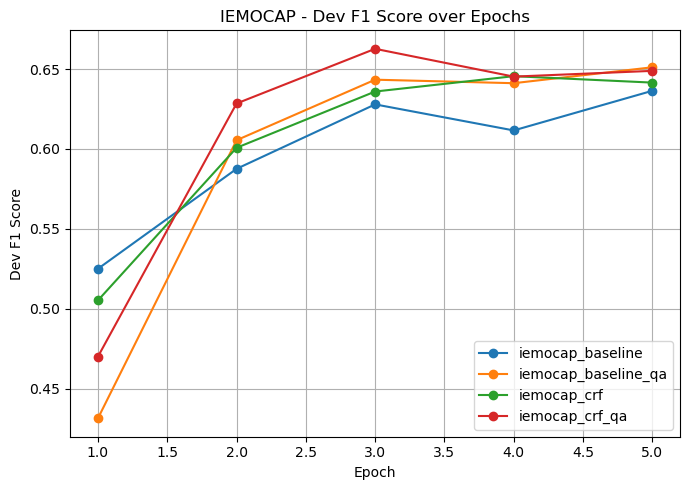

In [101]:
plot_lines(iemocap=iemocap_f1_results_1, metric="Dev F1 Score")

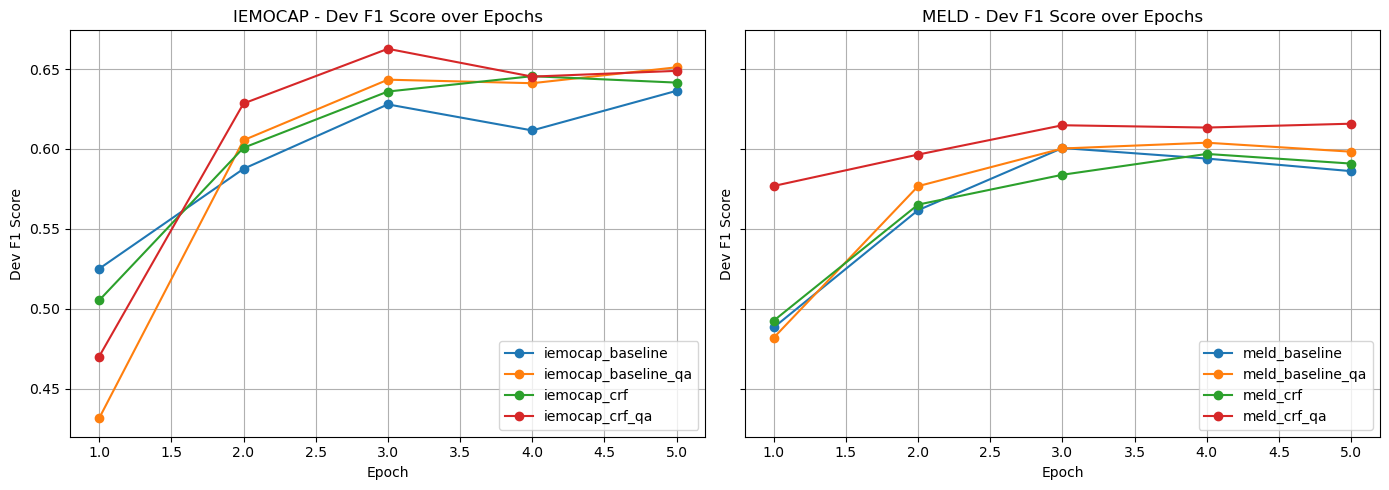

In [104]:
plot_lines(iemocap=iemocap_f1_results_1, meld=meld_f1_results_1, metric="Dev F1 Score")

In [74]:
# Clustered bar plots to show F1 by epoch and method
def plot_bars(iemocap, meld, metric):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    x_labels = ["baseline", "baseline_qa", "crf", "crf_qa"]
    epochs = range(1, 6)
    bar_width = 0.15
    group_spacing = 0.02  # adds a little gap between epochs

    # Create positions for each label/epoch combo
    x = np.arange(len(x_labels))
    total_width = bar_width * len(epochs) + group_spacing * (len(epochs) - 1)
    start_positions = x - total_width / 2 + bar_width / 2

    # IEMOCAP
    for i, epoch in enumerate(epochs):
        values = [iemocap[f"iemocap_{label}"].iloc[epoch - 1] for label in x_labels]
        positions = start_positions + i * (bar_width + group_spacing)
        axes[0].bar(positions, values, width=bar_width, label=f"Epoch {epoch}",
                    color=[method_colors[label] for label in x_labels])

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(x_labels)
    axes[0].set_title(f"IEMOCAP - {metric} per Method and Epoch")
    axes[0].set_ylabel(metric)

    # MELD
    for i, epoch in enumerate(epochs):
        values = [meld[f"meld_{label}"].iloc[epoch - 1] for label in x_labels]
        positions = start_positions + i * (bar_width + group_spacing)
        axes[1].bar(positions, values, width=bar_width, label=f"Epoch {epoch}",
                    color=[method_colors[label] for label in x_labels])

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(x_labels)
    axes[1].set_title(f"MELD - {metric} per Method and Epoch")

    # Shared legend
    plt.tight_layout()
    plt.show()

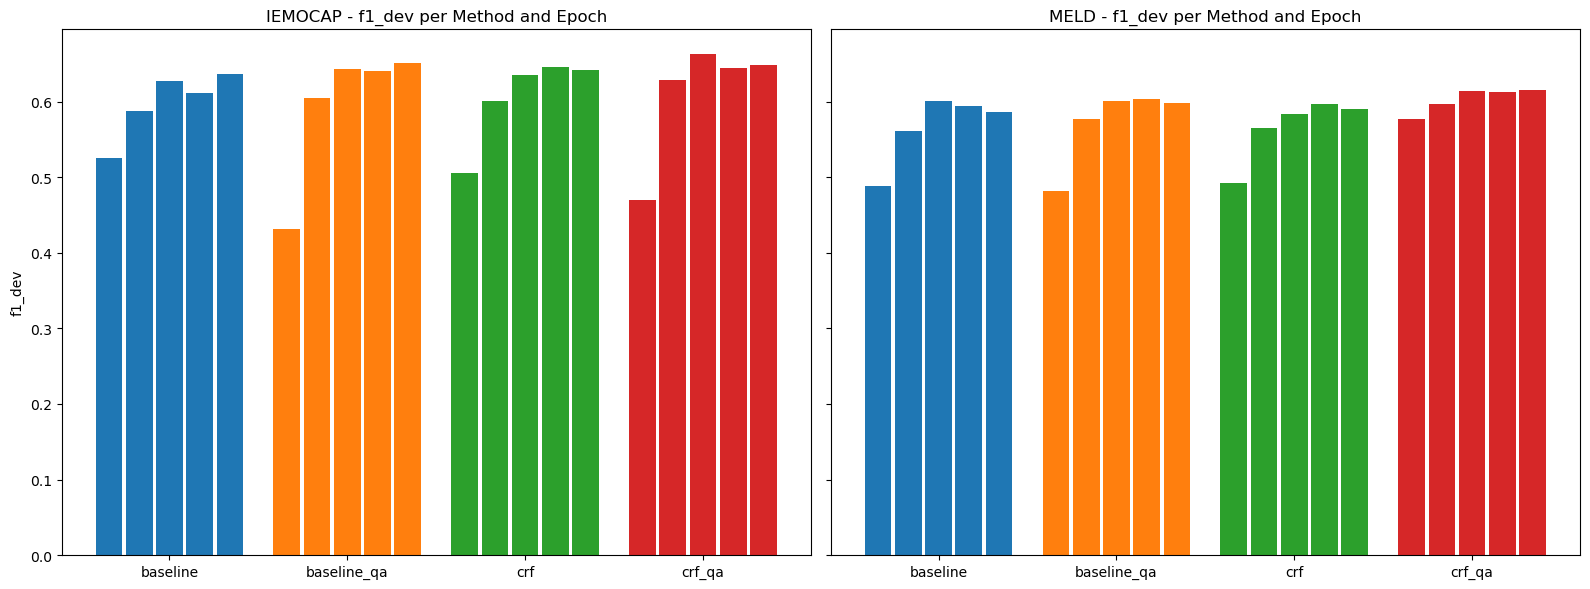

In [75]:
plot_bars(iemocap_f1_results_1, meld_f1_results_1, "f1_dev")

In [76]:
# create function to load the loss of selected experiment and dataset
def load_train_loss_by_epoch(experiment_number, dataset = None):
    base_path = f"{experiment_number}/"
    all_prefixes = ["iemocap", "meld"]
    suffixes = ["baseline", "baseline_qa", "crf", "crf_qa"]

    # Choose which dataset to include
    if dataset is not None:
        prefixes = [dataset]
    else:
        prefixes = all_prefixes

    f1_dev_dict = {}

    # Load files and copy train_loss results
    for prefix in prefixes:
        for suffix in suffixes:
            filename = f"{prefix}_{suffix}.csv"
            full_path = base_path + filename
            label = filename.replace(".csv", "")
            df = pd.read_csv(full_path)
            f1_dev_dict[label] = df["train_loss"]

    # Create DataFrame
    result_df = pd.DataFrame(f1_dev_dict)
    result_df.index = result_df.index + 1
    result_df.index.name = "epoch"

    # Sort columns: baseline -> baseline_qa -> crf -> crf_qa
    ordered_columns = [
        f"{prefix}_{suffix}"
        for prefix in prefixes
        for suffix in suffixes
    ]
    result_df = result_df[ordered_columns]

    return result_df

In [77]:
iemocap_loss_1 = load_train_loss_by_epoch(2, dataset="iemocap")

meld_loss_1 = load_train_loss_by_epoch(2, dataset="meld")

In [78]:
iemocap_loss_1

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,10.698685,10.834955,102.121464,102.291160
2,8.572372,8.620865,83.277627,82.031557
3,7.589144,7.154040,71.684628,69.701973
4,6.934656,6.492895,65.009107,63.199409
5,6.505406,6.050747,60.564976,58.998918


In [79]:
meld_loss_1

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,11.569098,11.291778,112.991784,109.367297
2,9.172927,8.920967,96.635456,88.337151
3,8.006770,7.796066,86.074142,80.292763
4,7.207920,7.148610,78.328012,74.447577
5,6.731179,6.651150,71.517357,67.912450


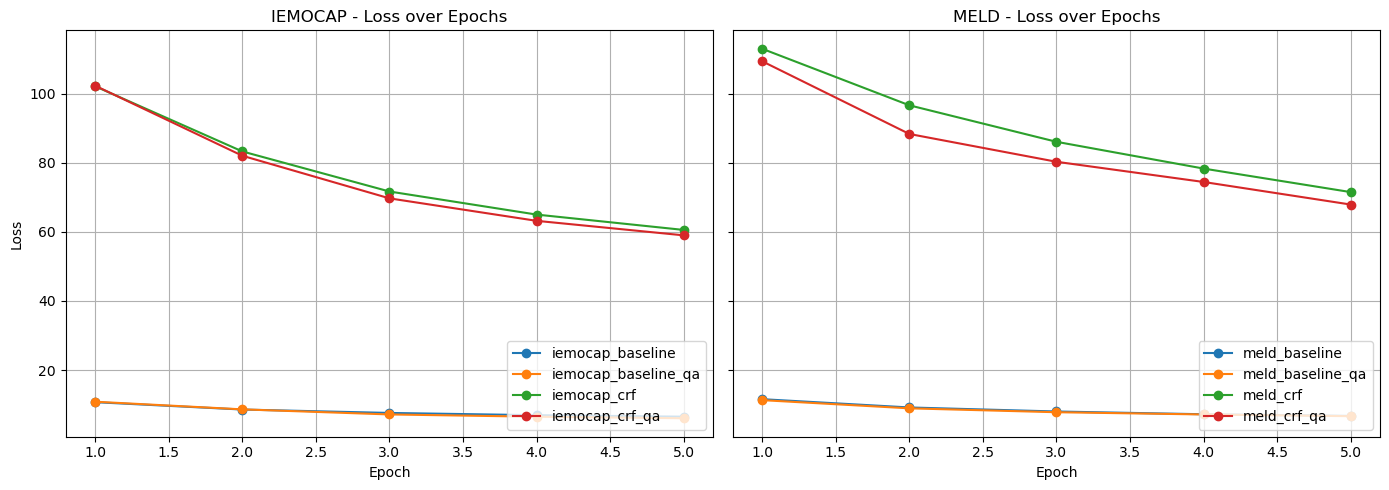

In [ ]:
plot_lines(iemocap=iemocap_loss_1, meld=meld_loss_1, metric="Loss")

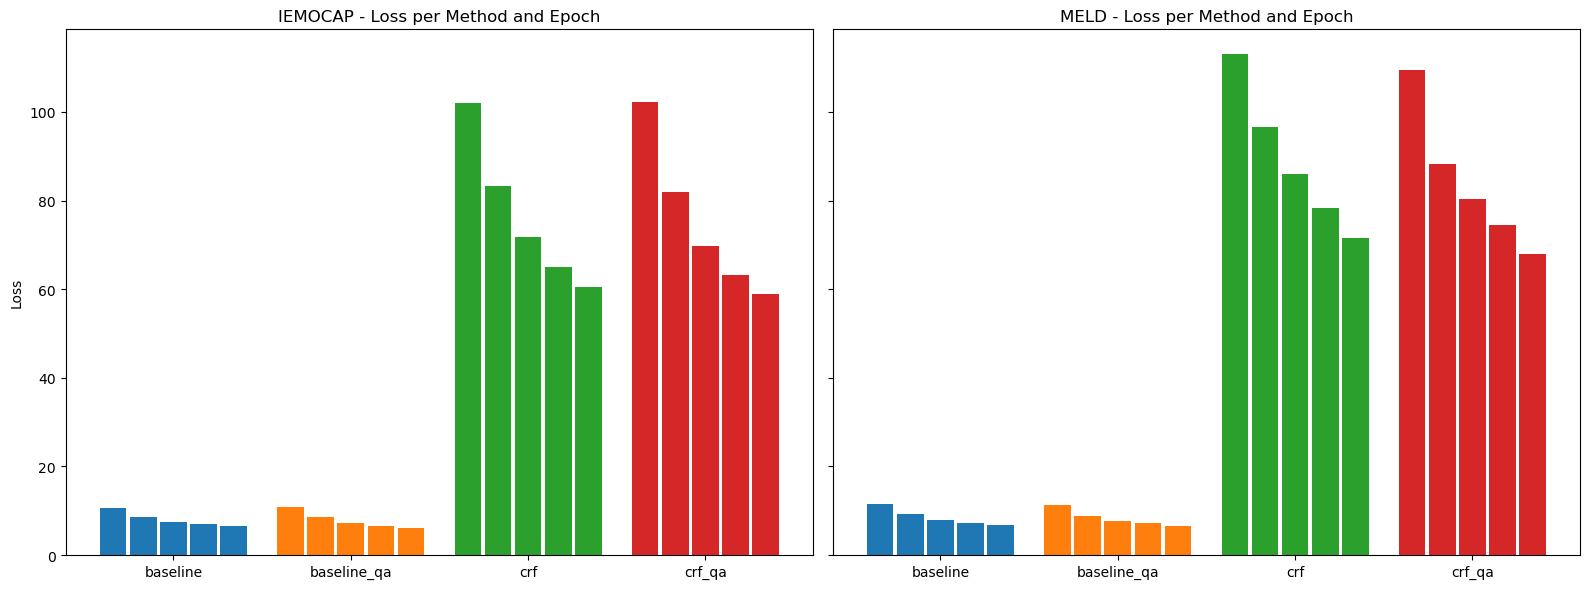

In [81]:
plot_bars(iemocap_loss_1, meld_loss_1, "Loss")

### Experiment 2

In [82]:
iemocap_f1_results_2 = load_f1_dev_by_epoch(3, dataset="iemocap")
meld_f1_results_2 = load_f1_dev_by_epoch(3, dataset="meld")
iemocap_loss_2 = load_train_loss_by_epoch(3, dataset="iemocap")
meld_loss_2 = load_train_loss_by_epoch(3, dataset="meld")

In [83]:
iemocap_f1_results_2

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,0.481117,0.511151,0.480301,0.478727
2,0.620427,0.624808,0.616096,0.617512
3,0.607947,0.615873,0.629797,0.626819
4,0.659000,0.653106,0.629399,0.604199
5,0.659814,0.664516,0.661346,0.655304
6,0.653538,0.683322,0.643372,0.694216


In [84]:
meld_f1_results_2

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,0.513938,0.551007,0.478812,0.578056
2,0.585070,0.590850,0.578856,0.614550
3,0.596129,0.598047,0.605467,0.625155
4,0.600457,0.602889,0.613209,0.621757
5,0.598447,0.614696,0.622998,0.622287
6,0.614233,0.616064,0.619847,0.625193


In [85]:
iemocap_loss_2

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,10.507111,10.468444,94.177377,94.016830
2,8.486260,8.497210,76.975450,77.333654
3,7.258290,7.217738,67.000637,68.143766
4,6.615300,6.551544,59.956159,60.780081
5,6.166694,6.057509,55.534528,56.153024
6,5.722358,5.545180,51.587337,51.019768


In [86]:
meld_loss_2

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,11.576564,11.316384,107.057261,98.252263
2,8.793757,8.701531,92.698774,85.527270
3,7.659343,7.652164,82.493400,77.720129
4,7.021873,7.091585,74.984692,71.555211
5,6.419344,6.486346,68.500818,65.631526
6,5.907812,5.981473,62.846229,60.067810


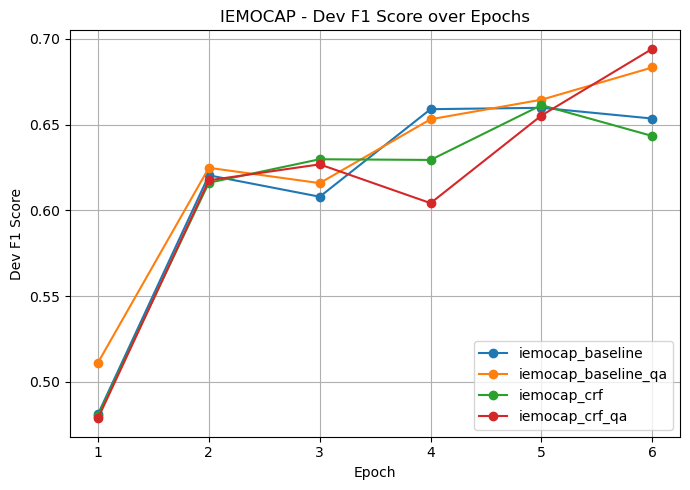

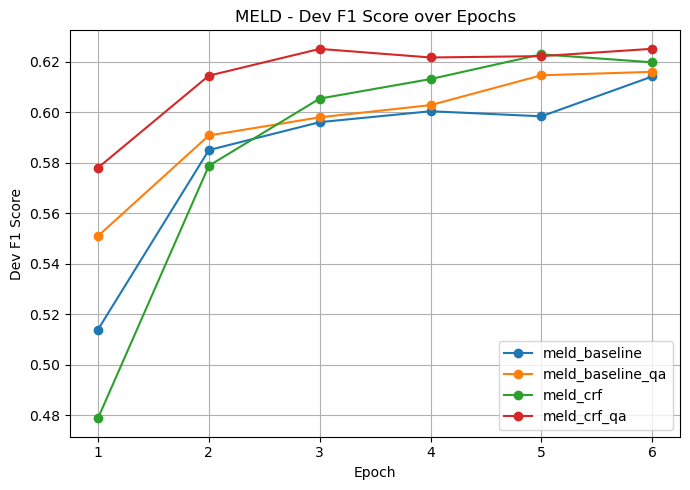

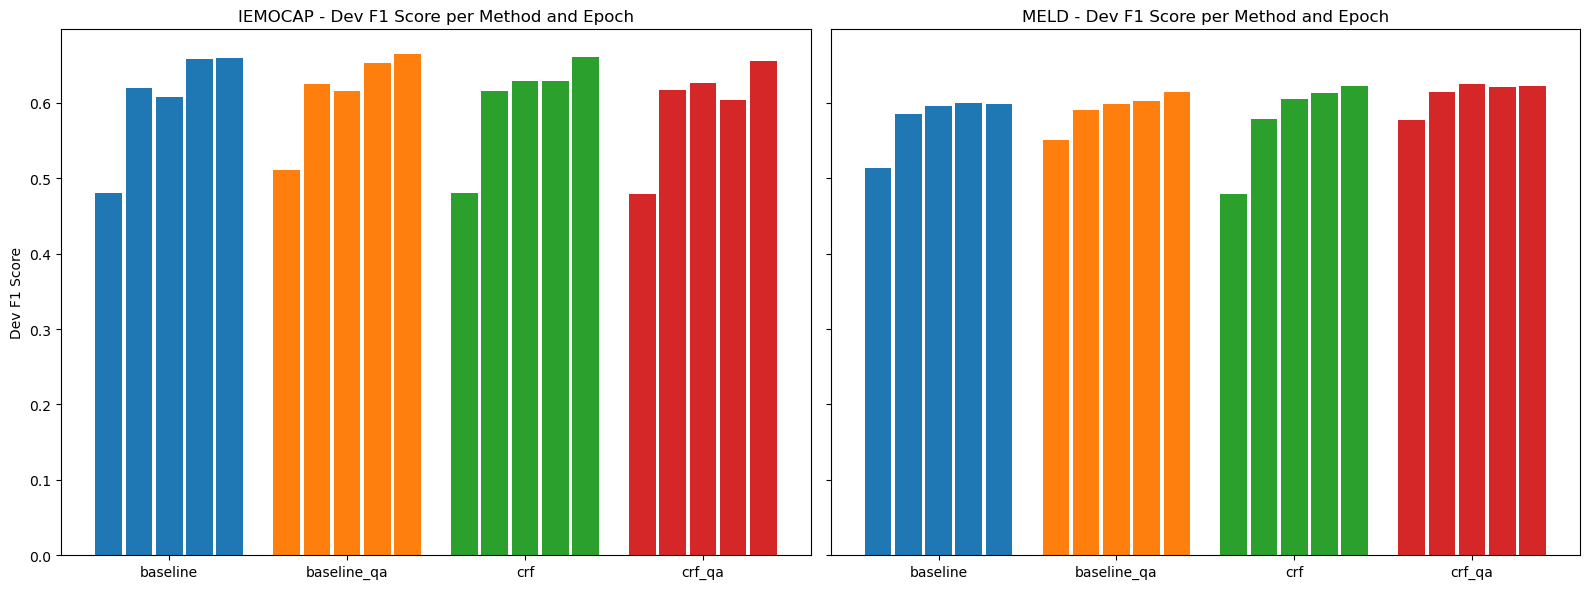

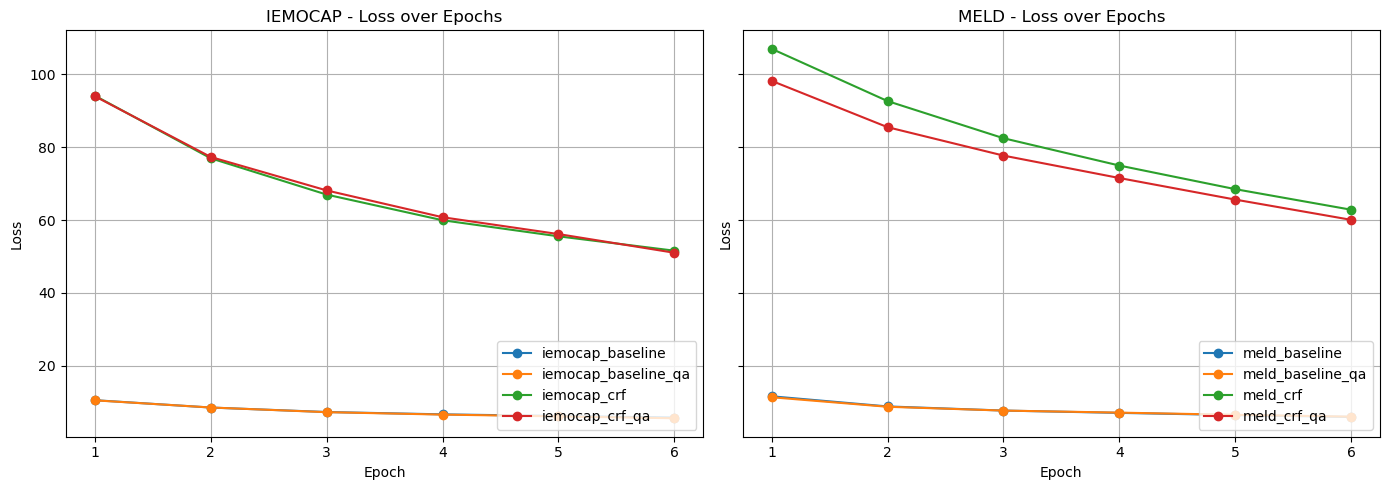

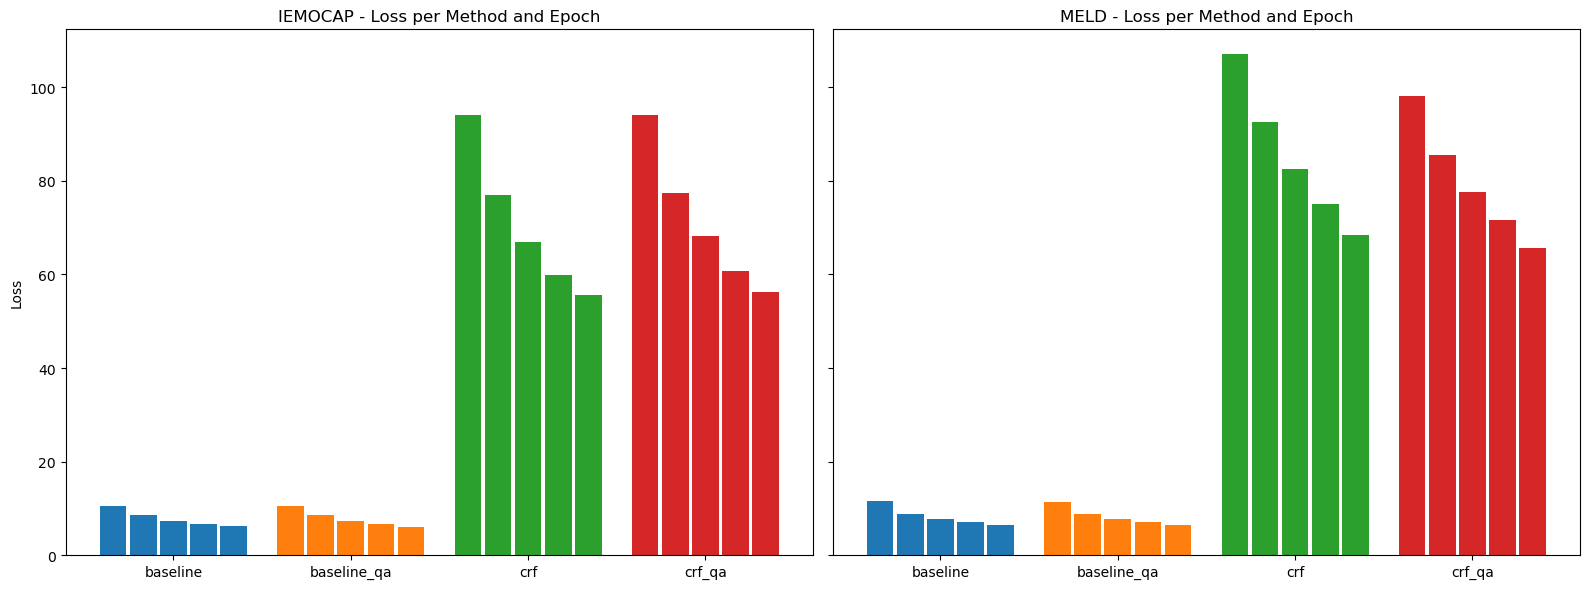

In [106]:
plot_lines(iemocap=iemocap_f1_results_2, metric="Dev F1 Score")
plot_lines(meld=meld_f1_results_2, metric="Dev F1 Score")
plot_bars(iemocap_f1_results_2, meld_f1_results_2, "Dev F1 Score")
plot_lines(iemocap=iemocap_loss_2, meld=meld_loss_2, metric="Loss")
plot_bars(iemocap_loss_2, meld_loss_2, "Loss")

### Experiment 3

In [112]:
iemocap_f1_results_3 = load_f1_dev_by_epoch(4, dataset="iemocap")
meld_f1_results_3 = load_f1_dev_by_epoch(4, dataset="meld")
iemocap_loss_3 = load_train_loss_by_epoch(4, dataset="iemocap")
meld_loss_3 = load_train_loss_by_epoch(4, dataset="meld")

In [113]:
iemocap_f1_results_3

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,0.513853,0.529067,0.476949,0.462803
2,0.608046,0.621804,0.621158,0.592101
3,0.623327,0.606843,0.626538,0.612819
4,0.646624,0.645582,0.636553,0.598944
5,0.652079,0.660796,0.652612,0.633317
6,0.652635,0.653536,0.654506,0.664981
7,0.653032,0.690787,0.654516,0.673706
8,0.658894,0.682949,0.653805,0.660037


In [114]:
meld_f1_results_3

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,0.492544,0.512146,0.507578,0.588411
2,0.574412,0.577138,0.579302,0.604679
3,0.581040,0.586164,0.601329,0.613167
4,0.603746,0.614221,0.605918,0.616444
5,0.599835,0.606469,0.610946,0.624437
6,0.599798,0.619424,0.625120,0.628987
7,0.610601,0.612021,0.611522,0.626075
8,0.606150,0.620990,0.613872,0.625782


In [115]:
iemocap_loss_3

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa
epoch,,,,
1,10.436329,10.397852,94.559965,94.527454
2,8.302487,8.292405,78.172601,77.039732
3,7.062758,7.128775,67.521317,67.896587
4,6.553843,6.521720,60.406291,60.201807
5,6.133139,6.034331,56.773378,55.793084
6,5.683971,5.532536,53.151447,52.007055
7,5.366721,5.207548,49.164128,47.955276
8,4.995729,4.810401,46.885088,44.421572


In [116]:
meld_loss_3

,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
epoch,,,,
1,11.545557,11.395913,106.841113,99.180750
2,9.093379,8.876167,93.490654,85.848820
3,7.900833,7.737694,83.384196,78.489556
4,7.246265,7.094251,75.705737,72.278299
5,6.658547,6.529556,68.826584,65.798167
6,6.171074,6.022121,64.608081,61.546988
7,5.715162,5.531781,58.595428,55.995092
8,5.280052,5.134258,53.134906,51.026107


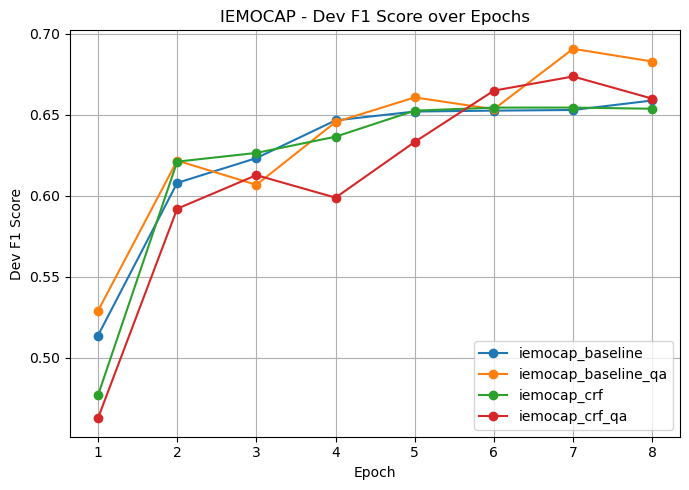

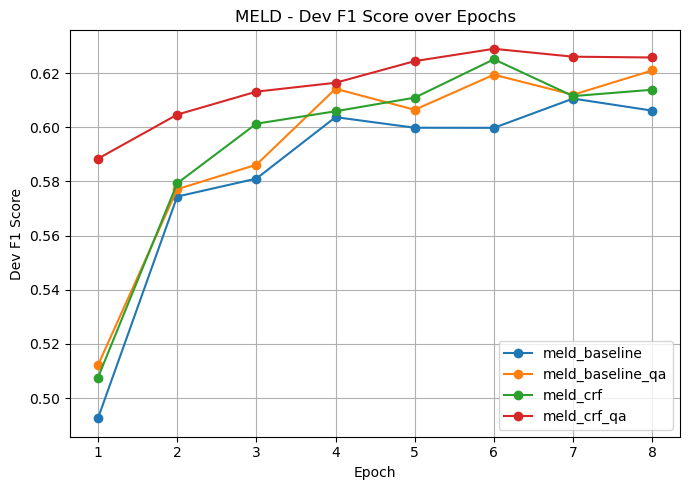

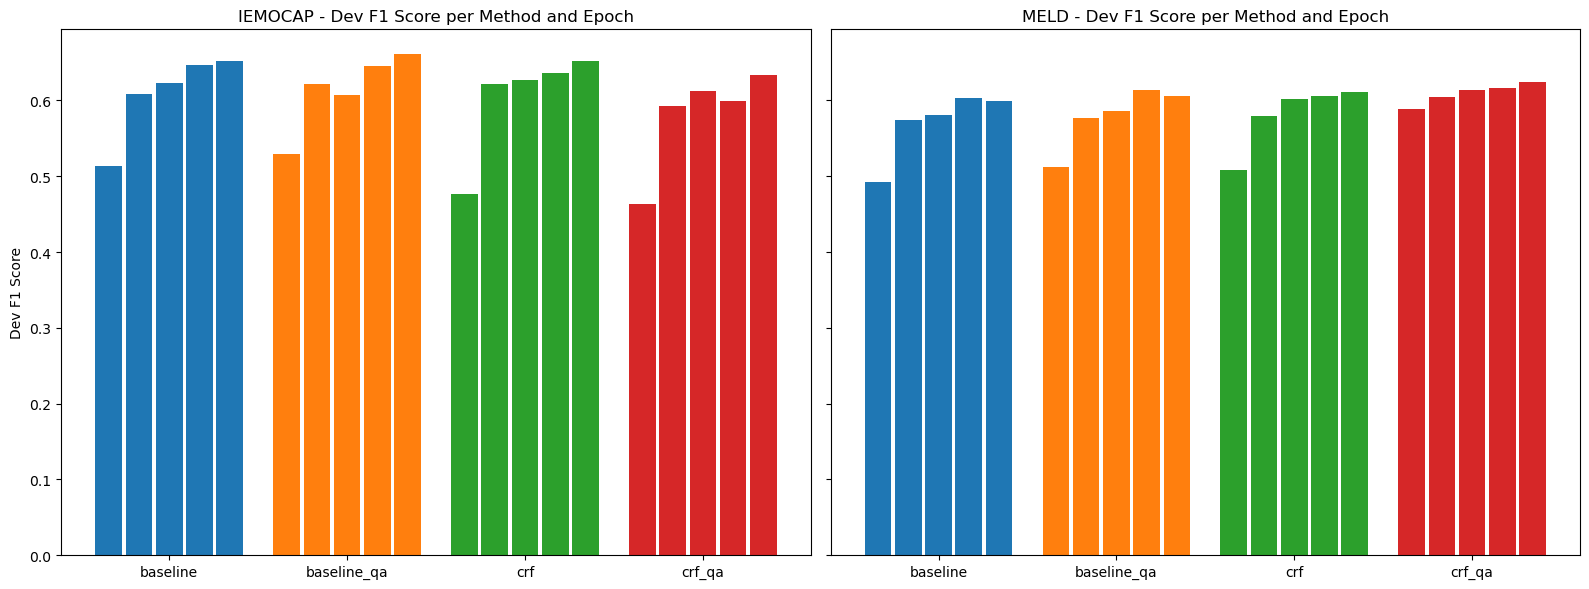

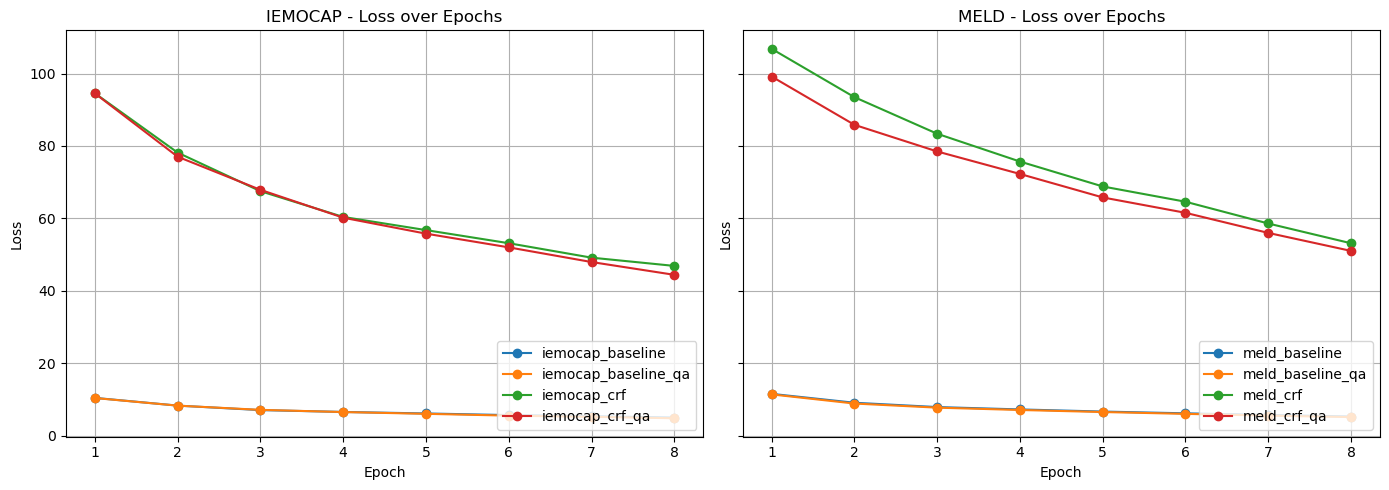

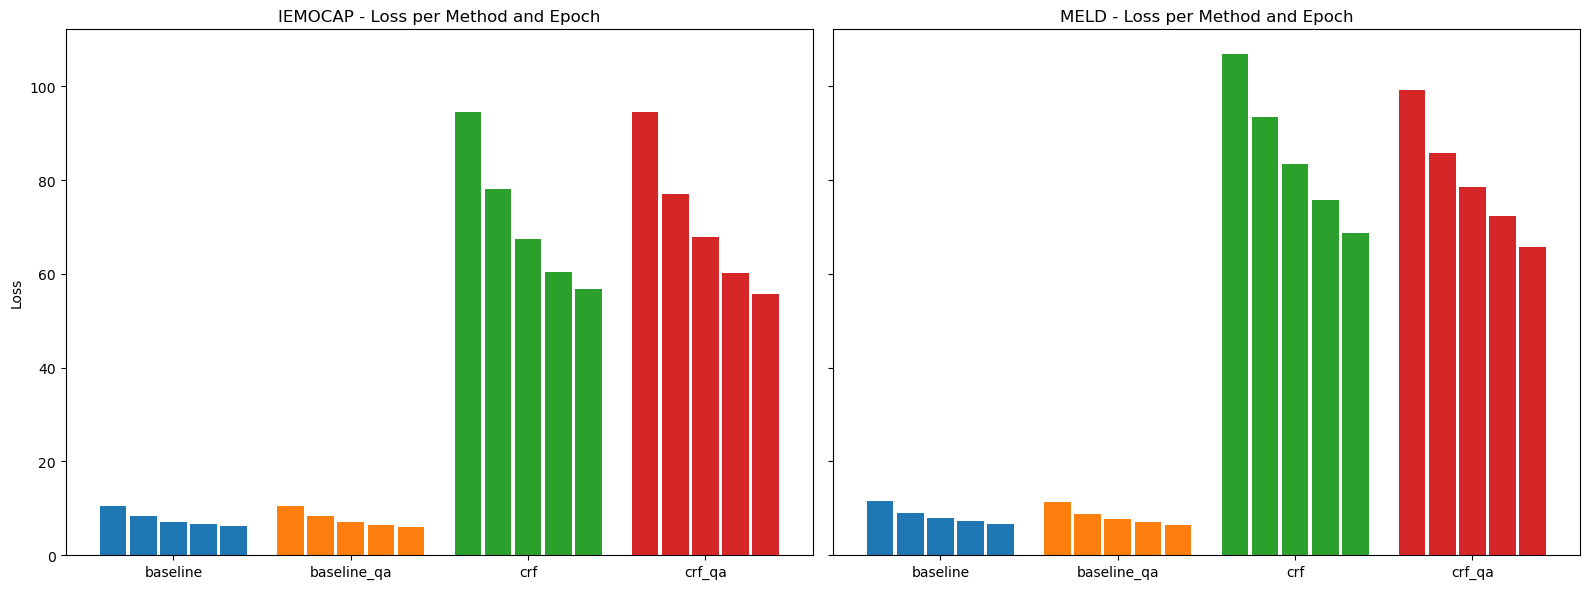

In [117]:
plot_lines(iemocap=iemocap_f1_results_3, metric="Dev F1 Score")
plot_lines(meld=meld_f1_results_3, metric="Dev F1 Score")
plot_bars(iemocap_f1_results_3, meld_f1_results_3, "Dev F1 Score")
plot_lines(iemocap=iemocap_loss_3, meld=meld_loss_3, metric="Loss")
plot_bars(iemocap_loss_3, meld_loss_3, "Loss")

### Experiments Summary

In [88]:
methods = ["baseline", "baseline_qa", "crf", "crf_qa"]

In [109]:
# List of experiment numbers you want to include
experiment_numbers = [2, 3, 4]
datasets = ["iemocap", "meld"]
methods = ["baseline", "baseline_qa", "crf", "crf_qa"]

# Initialize list for rows
rows = []

for exp_num in experiment_numbers:
    row = {"experiment": exp_num}
    for dataset in datasets:
        df = load_f1_dev_by_epoch(exp_num, dataset=dataset)
        for method in methods:
            col_name = f"{dataset}_{method}"
            max_f1 = df[col_name].max()
            row[f"{dataset}_{method}"] = max_f1
    rows.append(row)

# Convert to DataFrame
summary_df = pd.DataFrame(rows)
summary_df.set_index("experiment", inplace=True)

In [110]:
summary_df

,iemocap_baseline,iemocap_baseline_qa,iemocap_crf,iemocap_crf_qa,meld_baseline,meld_baseline_qa,meld_crf,meld_crf_qa
experiment,,,,,,,,
2,0.636366,0.651072,0.645513,0.662635,0.600594,0.603912,0.596893,0.615798
3,0.659814,0.683322,0.661346,0.694216,0.614233,0.616064,0.622998,0.625193
4,0.658894,0.690787,0.654516,0.673706,0.610601,0.620990,0.625120,0.628987
